<a href="https://colab.research.google.com/github/05ravidubey/Projects_ML/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Objective-Predict sales based on advertising spend.**

In [191]:
import pandas as pd
df=pd.read_csv("/content/Advertising.csv")

In [192]:
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## **Data info**

In [193]:
df.columns

Index(['Unnamed: 0', 'TV', 'radio', 'newspaper', 'sales'], dtype='object')

In [194]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [195]:
df.shape

(200, 5)

# EDA

In [196]:
df.describe()

,Unnamed: 0,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [197]:
df.isnull().sum()

,0
Unnamed: 0,0
TV,0
radio,0
newspaper,0
sales,0


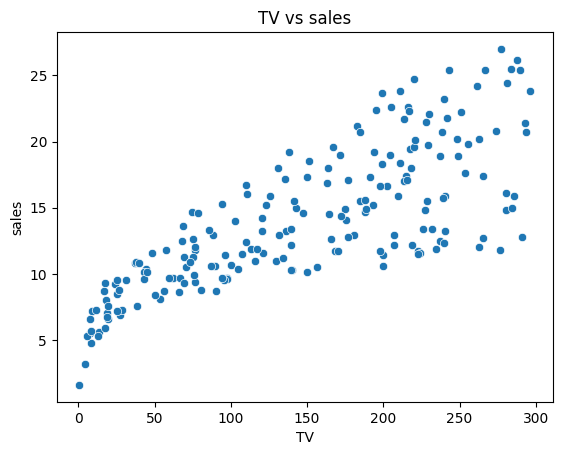

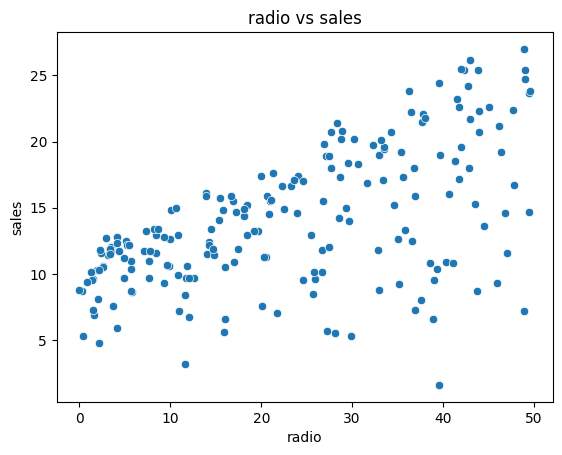

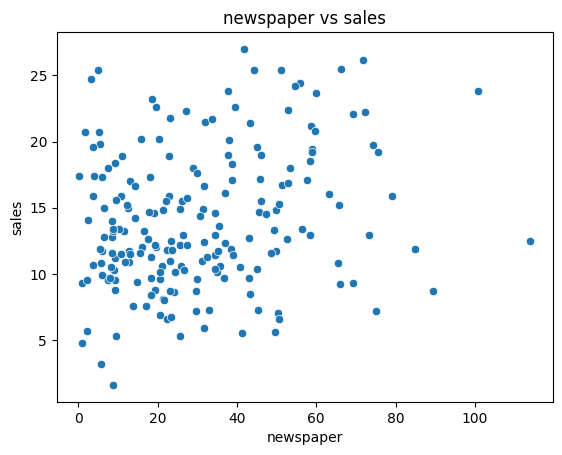

In [198]:
import seaborn as sns
import matplotlib.pyplot as plt

# Individual relationships
sns.scatterplot(x=df["TV"], y=df["sales"])
plt.title("TV vs sales")
plt.show()

sns.scatterplot(x=df["radio"], y=df["sales"])
plt.title("radio vs sales")
plt.show()

sns.scatterplot(x=df["newspaper"], y=df["sales"])
plt.title("newspaper vs sales")
plt.show()

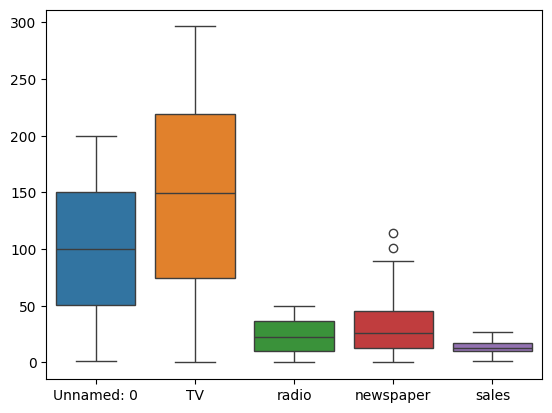

In [199]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df)
plt.show()

In [ ]:
## There are 2 outlier points

In [201]:
import numpy as np

# Define limits (5% and 95%)
lower = df["newspaper"].quantile(0.05)
upper = df["newspaper"].quantile(0.95)

df["newspaper_wins"] = np.where(
    df["newspaper"] < lower, lower,
    np.where(df["newspaper"] > upper, upper, df["newspaper"])
)

In [202]:
df.head()

,Unnamed: 0,TV,radio,newspaper,sales,newspaper_wins
0,1,230.1,37.8,69.2,22.1,69.2
1,2,44.5,39.3,45.1,10.4,45.1
2,3,17.2,45.9,69.3,9.3,69.3
3,4,151.5,41.3,58.5,18.5,58.5
4,5,180.8,10.8,58.4,12.9,58.4


In [203]:
df["newspaper_log"] = np.log1p(df["newspaper_wins"])

In [204]:
df.head()

,Unnamed: 0,TV,radio,newspaper,sales,newspaper_wins,newspaper_log
0,1,230.1,37.8,69.2,22.1,69.2,4.251348
1,2,44.5,39.3,45.1,10.4,45.1,3.830813
2,3,17.2,45.9,69.3,9.3,69.3,4.252772
3,4,151.5,41.3,58.5,18.5,58.5,4.085976
4,5,180.8,10.8,58.4,12.9,58.4,4.084294


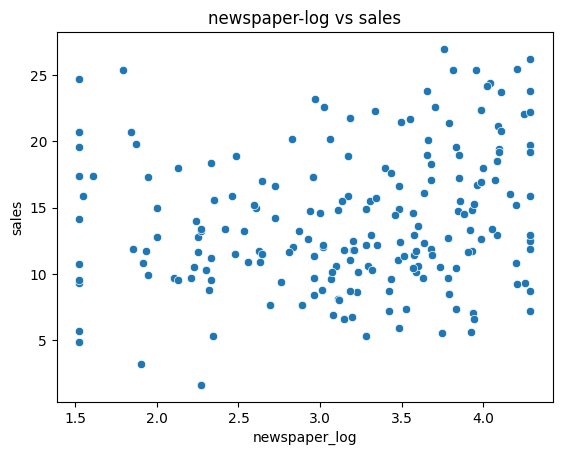

In [205]:
sns.scatterplot(x=df["newspaper_log"], y=df["sales"])
plt.title("newspaper-log vs sales")
plt.show()

In [155]:
df.head()

,Unnamed: 0,TV,radio,newspaper,sales,newspaper_wins,newspaper_log
0,1,230.1,37.8,4.251348,22.1,4.251348,1.658485
1,2,44.5,39.3,3.830813,10.4,3.830813,1.575015
2,3,17.2,45.9,4.252772,9.3,4.252772,1.658756
3,4,151.5,41.3,4.085976,18.5,4.085976,1.626487
4,5,180.8,10.8,4.084294,12.9,4.084294,1.626156


In [157]:
import seaborn as sns
import matplotlib.pyplot as plt

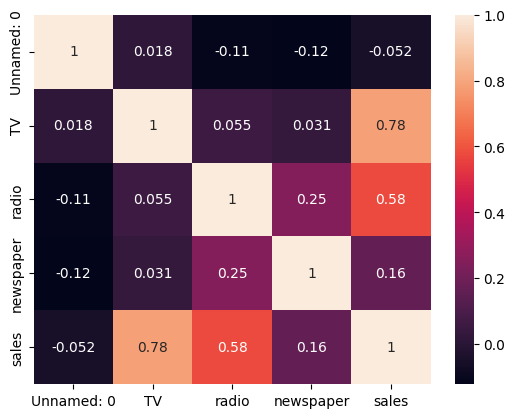

In [138]:
sns.heatmap(df.corr(),annot=True)
plt.show()

In [76]:
##### From the above plot we can see that there is no multicollearity

Creating Features and Target

In [167]:
X = df[['TV', 'radio', 'newspaper_log']]
y = df['sales']

**Train Test split**

In [168]:
from sklearn.model_selection import train_test_split

In [169]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

**Feature Scaling**

In [170]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Train the** **model**

In [171]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

**Predictiion and Evaluation**

In [172]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print results
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 1.4634024671676198
MSE : 3.1567249873361094
RMSE: 1.7767174753843418
R2  : 0.8999884166442198


In [173]:

y_train_pred = lr.predict(X_train)

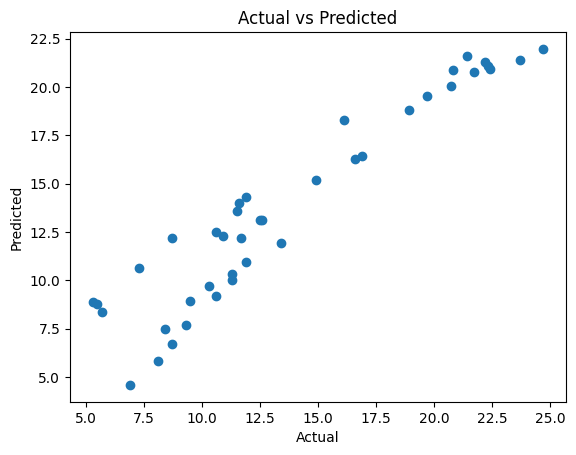

In [174]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
##### Showing strong positive linear pattern so this meaans models has learn the relastion ship well.(All points should lie on a 45 degree straight line)

**To understad the performance we are doing Actual vs Predicted comaparision**

In [176]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison.head())

   Actual  Predicted
0    16.9  16.430451
1    22.4  20.911913
2    21.4  21.593541
3     7.3  10.628573
4    24.7  21.975151


In [206]:
model = LinearRegression()
model.fit(X_train, y_train)

print(model.coef_)
print(X.columns)

[3.76925107 2.79017554 0.0879622 ]
Index(['TV', 'radio', 'newspaper_log'], dtype='object')


<Axes: xlabel='sales', ylabel='Count'>

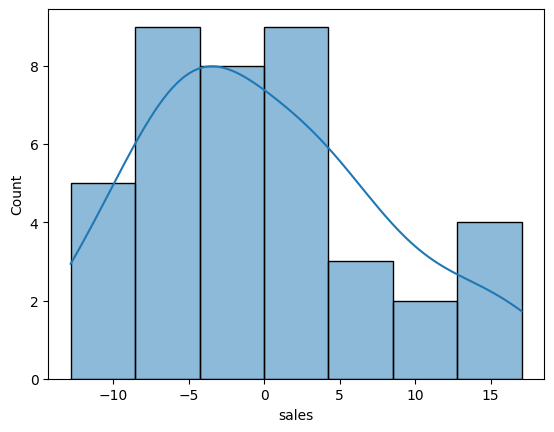

In [178]:
sns.histplot(residuals, kde=True)

**Cross Validation**

In [179]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print(cv_scores)
print("Mean CV Score:", cv_scores.mean())

[0.87763911 0.917715   0.93014859 0.81859859 0.89554617]
Mean CV Score: 0.8879294930304363


In [ ]:
0.899 - 0.885 = 0.014 (~1.4%) ### This is very small it tell that there is no overfitting

**Now Applying Ridge and Lasso Regression for improve performance**

In [180]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

lr = LinearRegression()
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.1)

lr.fit(X_train, y_train)
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

Lasso(alpha=0.1)

In [181]:
y_pred_lr = lr.predict(X_test)
y_pred_ridge = ridge.predict(X_test)
y_pred_lasso = lasso.predict(X_test)

In [90]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    return mae, mse, rmse, r2

In [182]:
mae_lr, mse_lr, rmse_lr, r2_lr = evaluate(y_test, y_pred_lr)

print("Linear Regression")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2:", r2_lr)

Linear Regression
MAE: 1.4634024671676198
RMSE: 1.7767174753843418
R2: 0.8999884166442198


In [183]:
mae_r, mse_r, rmse_r, r2_r = evaluate(y_test, y_pred_ridge)

print("\nRidge")
print("MAE:", mae_r)
print("RMSE:", rmse_r)
print("R2:", r2_r)


Ridge
MAE: 1.4653259584869658
RMSE: 1.78097777268035
R2: 0.8995082165895174


In [184]:
mae_l, mse_l, rmse_l, r2_l = evaluate(y_test, y_pred_lasso)

print("\nLasso")
print("MAE:", mae_l)
print("RMSE:", rmse_l)
print("R2:", r2_l)


Lasso
MAE: 1.4616526067206488
RMSE: 1.7913826468664027
R2: 0.8983305952765889


In [185]:
results = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Lasso"],
    "MAE": [mae_lr, mae_r, mae_l],
    "RMSE": [rmse_lr, rmse_r, rmse_l],
    "R2": [r2_lr, r2_r, r2_l]
})

print(results)

    Model       MAE      RMSE        R2
0  Linear  1.463402  1.776717  0.899988
1   Ridge  1.465326  1.780978  0.899508
2   Lasso  1.461653  1.791383  0.898331


**By comparing all 3 model we can see that there is no differnce. So our model is good.**

In [96]:
from sklearn.model_selection import cross_val_score

cv_lr = cross_val_score(lr, X, y, cv=5, scoring='r2')
cv_ridge = cross_val_score(ridge, X, y, cv=5, scoring='r2')
cv_lasso = cross_val_score(lasso, X, y, cv=5, scoring='r2')

print("CV Linear:", cv_lr.mean())
print("CV Ridge:", cv_ridge.mean())
print("CV Lasso:", cv_lasso.mean())

CV Linear: 0.8877746326163092
CV Ridge: 0.8877747532220847
CV Lasso: 0.8877776446006129


**Finally we calculated the cvscore of all  model they are also same **

**Now trying the same by dropping column "newspaper"**

In [207]:
X = df[['TV', 'radio',]]
y = df['sales']

In [208]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [209]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [210]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [211]:
y_pred = model.predict(X_test)

In [212]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 1.4443023138227578
MSE: 3.1379480090683534
RMSE: 1.7714254173033517
R2: 0.9005833101920356


In [213]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print(cv_scores)
print("Mean CV Score:", cv_scores.mean())

[0.88116273 0.91814589 0.92984129 0.82185938 0.8954055 ]
Mean CV Score: 0.889282957306453


In [ ]:
#### Then also same result is coming